# 01 · EDA de calidad de datos + nota de sesgo (Issue #11)

**Responsable:** Integrante 1 (Datos) · **Fase CRISP-ML:** 4 (QA) · **Insumo directo:** auditoría de sesgo de Integrante 3 (#31/#32).

Análisis exploratorio sobre el **dataset analítico unificado** (`data/03_primary/dataset_analitico.parquet`),
una fila por `(cod_localidad × anio × tipo_delito)`. Documenta **calidad del dato** (cobertura, completitud,
distribuciones) y, sobre todo, los **sesgos potenciales** que el modelo predictivo y el clustering podrían
replicar si se usan sin cuidado.

> **Sin fuga:** este EDA describe todo el histórico para caracterizar el dato, pero las decisiones de
> modelado usan solo `split == "train"` (2018–2024). Las filas `test` (2025) no se analizan para aprender nada.

**Secciones**
1. Cobertura y completitud
2. Distribución de delitos
3. Correlaciones
4. **Nota de sesgo de sobre-vigilancia** ← la más importante para el jurado

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Paleta del proyecto (consistente con dashboard y app móvil)
COLORES = {
    "bajo":   "#17D05B",   # verde  · bajo riesgo
    "medio":  "#F5A623",   # naranja· medio
    "alto":   "#E05252",   # rojo   · alto riesgo
    "neutro": "#C89B3C",   # dorado
    "fondo":  "#0D1117",
}
CMAP_RIESGO = "RdYlGn_r"   # rojo = alto, verde = bajo

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.axisbelow": True})
sns.set_style("whitegrid")

DF = pd.read_parquet("../data/03_primary/dataset_analitico.parquet")
# localidad_nombre puede venir como arrow-string; normalizar a str de Python para plots
DF["localidad_nombre"] = DF["localidad_nombre"].astype("string").astype(object)
print("Dataset:", DF.shape, "| columnas:", list(DF.columns))
HIST = DF[DF["anio"] <= 2024].copy()   # histórico de entrenamiento
print("Histórico train (<=2024):", HIST.shape[0], "filas |",
      "años:", sorted(DF["anio"].unique()))
DF.head()

Dataset: (1760, 11) | columnas: ['cod_localidad', 'localidad_nombre', 'anio', 'tipo_delito', 'tipo_delito_nombre', 'conteo_siedco', 'conteo_nuse', 'poblacion', 'ipm_nbi', 'split', 'riesgo_alto']
Histórico train (<=2024): 1540 filas | años: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,cod_localidad,localidad_nombre,anio,tipo_delito,tipo_delito_nombre,conteo_siedco,conteo_nuse,poblacion,ipm_nbi,split,riesgo_alto
0,01,USAQUEN,2018,DS,Delitos Sexuales,263,223460,534118,2.424007,train,0
1,01,USAQUEN,2018,H,Homicidios,36,223460,534118,2.424007,train,0
2,01,USAQUEN,2018,HA,Hurto Automotores,158,223460,534118,2.424007,train,0
3,01,USAQUEN,2018,HB,Hurto Bicicletas,789,223460,534118,2.424007,train,1
4,01,USAQUEN,2018,HC,Hurto Comercio,1295,223460,534118,2.424007,train,1


## Sección 1 — Cobertura y completitud

¿Tenemos dato para cada localidad en cada año, o hay huecos? ¿Cuánto pesa el faltante conocido (`ipm_nbi`
en Sumapaz)? ¿Cómo se reparte el volumen de llamadas al 123 (`conteo_nuse`)?

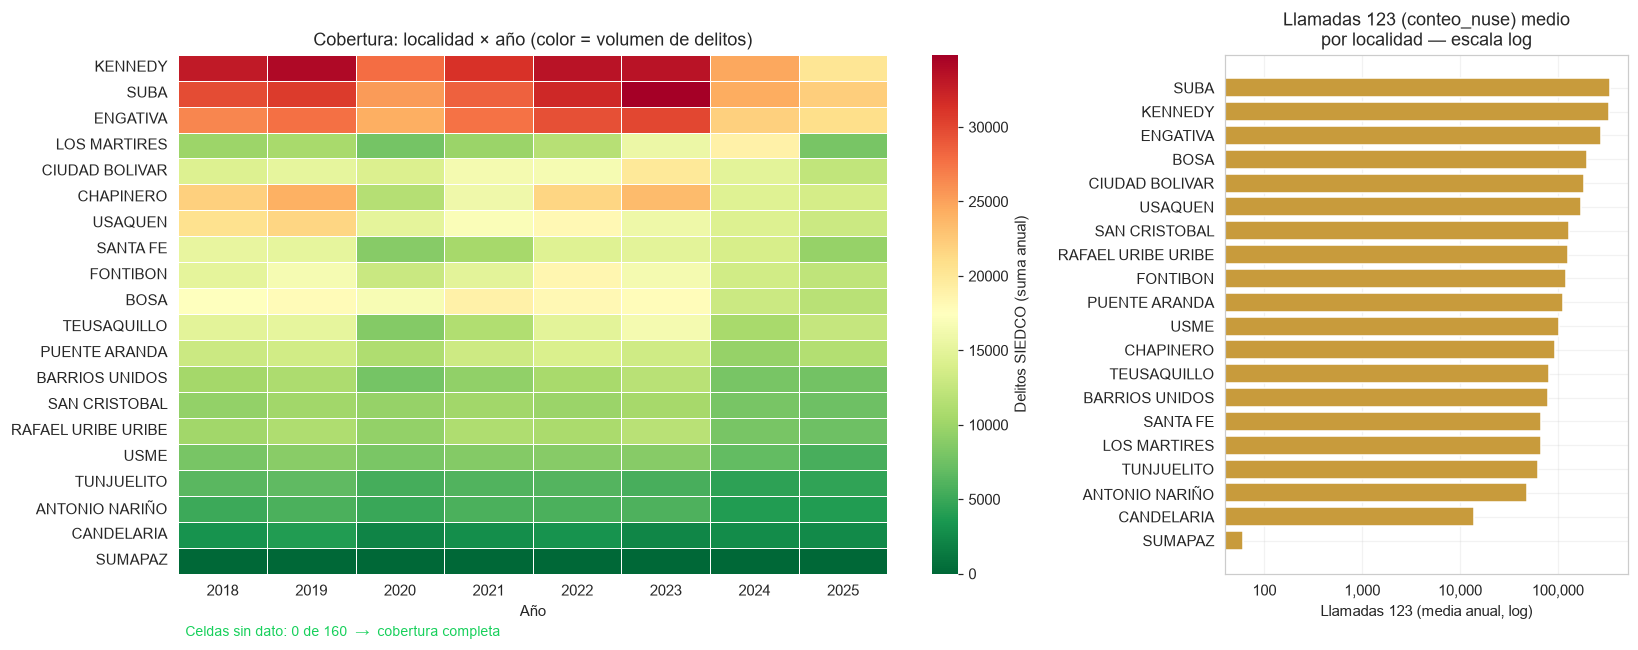

ipm_nbi nulo: 88 filas (5.0%) — localidad(es): ['SUMAPAZ']
conteo_nuse — rango por localidad: min 61 (SUMAPAZ) → max 338,277 (SUBA)


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios":[2.2, 1]})

# (a) Heatmap localidad x año, coloreado por total de delitos SIEDCO
cov = (DF.pivot_table(index="localidad_nombre", columns="anio",
                      values="conteo_siedco", aggfunc="sum")
         .sort_values(2024, ascending=False))
sns.heatmap(cov, cmap=CMAP_RIESGO, ax=axes[0], linewidths=.4, linecolor="white",
            cbar_kws={"label": "Delitos SIEDCO (suma anual)"},
            annot=False, fmt=",")
axes[0].set_title("Cobertura: localidad × año (color = volumen de delitos)")
axes[0].set_xlabel("Año"); axes[0].set_ylabel("")

n_nan = int(cov.isna().sum().sum())
axes[0].text(0.01, -0.12, f"Celdas sin dato: {n_nan} de {cov.size}  →  cobertura completa",
             transform=axes[0].transAxes, fontsize=9, color=COLORES["bajo"])

# (b) conteo_nuse medio por localidad (escala log: Sumapaz ~60 vs Suba ~338k)
nuse = DF.groupby("localidad_nombre")["conteo_nuse"].mean().sort_values()
axes[1].barh(nuse.index, nuse.values, color=COLORES["neutro"])
axes[1].set_xscale("log")
axes[1].set_title("Llamadas 123 (conteo_nuse) medio\npor localidad — escala log")
axes[1].set_xlabel("Llamadas 123 (media anual, log)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
plt.tight_layout(); plt.show()

# Completitud de ipm_nbi
nulos = DF["ipm_nbi"].isna()
print(f"ipm_nbi nulo: {nulos.sum()} filas ({nulos.mean()*100:.1f}%) — "
      f"localidad(es): {DF.loc[nulos,'localidad_nombre'].unique().tolist()}")
print(f"conteo_nuse — rango por localidad: min {int(nuse.min()):,} (SUMAPAZ) "
      f"→ max {int(nuse.max()):,} (SUBA)")

**Interpretación.** La malla `localidad × año` está **completa**: las 20 localidades tienen registro en
los 8 años (0 celdas vacías), así que no hay huecos que imputar en el eje espacio-temporal. El único faltante
estructural es **`ipm_nbi` en Sumapaz** (5.0% de las filas): la Encuesta Multipropósito no cubre esa localidad
rural. **No se imputa en silencio** — la decisión de imputación se deja a Integrante 2 como *feature* (ver
`variable_objetivo.md`); la variable objetivo `riesgo_alto` no depende de `ipm_nbi`. El volumen de llamadas al
123 abarca **cuatro órdenes de magnitud** (Sumapaz ~60 vs Suba ~338.000), por eso se grafica en escala log:
esa dispersión enorme es la razón de trabajar con tasas y percentiles por tipo, no con conteos crudos.

## Sección 2 — Distribución de delitos

¿Dónde se concentra el volumen? ¿Cómo evolucionó en el tiempo (incluido el valle de 2020)? ¿Qué tipos de
delito dominan el conteo?

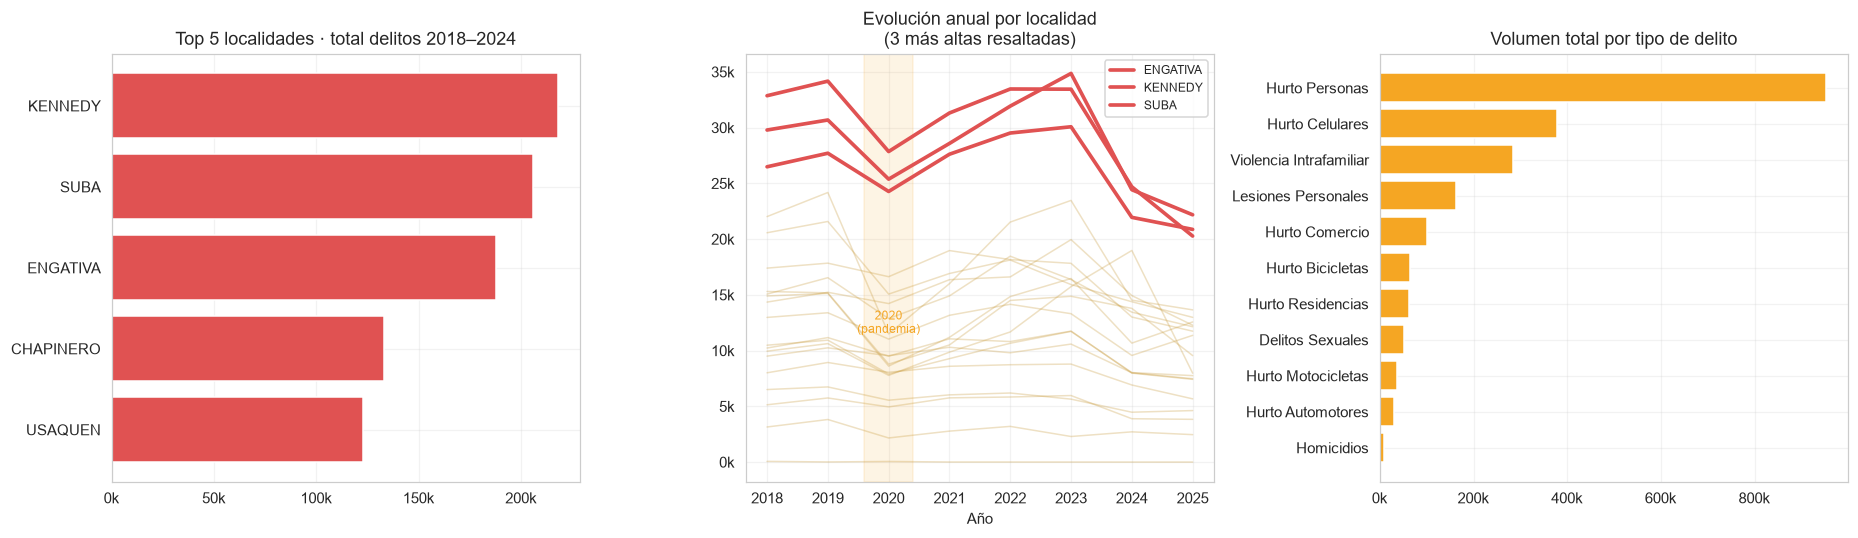

Caída 2020 vs 2019: -22.7%
Top tipo: Hurto Personas (951,989) | Menor: Homicidios (8,786)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) Top 5 localidades por conteo total 2018-2024
top5 = (HIST.groupby("localidad_nombre")["conteo_siedco"].sum()
            .sort_values(ascending=False).head(5))
axes[0].barh(top5.index[::-1], top5.values[::-1], color=COLORES["alto"])
axes[0].set_title("Top 5 localidades · total delitos 2018–2024")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x/1000)}k"))

# (b) Evolución temporal por localidad (línea tenue) + 3 extremas resaltadas
serie = DF.pivot_table(index="anio", columns="localidad_nombre",
                       values="conteo_siedco", aggfunc="sum")
extremas = serie.loc[2024].sort_values(ascending=False).index[:3].tolist()
for loc in serie.columns:
    es_ext = loc in extremas
    axes[1].plot(serie.index, serie[loc],
                 color=(COLORES["alto"] if es_ext else COLORES["neutro"]),
                 alpha=(1.0 if es_ext else 0.3),
                 lw=(2.4 if es_ext else 1.0),
                 label=(loc if es_ext else None))
axes[1].axvspan(2019.6, 2020.4, color=COLORES["medio"], alpha=0.12)
axes[1].annotate("2020\n(pandemia)", xy=(2020, serie.loc[2020].sum()/20),
                 fontsize=8, ha="center", color=COLORES["medio"])
axes[1].set_title("Evolución anual por localidad\n(3 más altas resaltadas)")
axes[1].set_xlabel("Año"); axes[1].legend(fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x/1000)}k"))

# (c) Distribución por tipo de delito
tipos = (DF.groupby("tipo_delito_nombre")["conteo_siedco"].sum()
           .sort_values())
axes[2].barh(tipos.index, tipos.values, color=COLORES["medio"])
axes[2].set_title("Volumen total por tipo de delito")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x/1000)}k"))
plt.tight_layout(); plt.show()

anual = DF.groupby("anio")["conteo_siedco"].sum()
caida = (anual[2020]/anual[2019]-1)*100
print(f"Caída 2020 vs 2019: {caida:.1f}%")
print("Top tipo:", tipos.index[-1], f"({int(tipos.iloc[-1]):,}) |",
      "Menor:", tipos.index[0], f"({int(tipos.iloc[0]):,})")

**Interpretación.** El volumen se concentra en las localidades **grandes y de alta afluencia**: Kennedy,
Suba y Engativá encabezan por tamaño poblacional, seguidas de Chapinero y Usaquén (comerciales). En el tiempo
se ve un **valle claro en 2020 (−22,7% frente a 2019)**: el confinamiento por COVID-19 redujo la exposición
en calle y, con ella, el delito registrado — es un efecto de contexto, no una mejora estructural, y hay que
tenerlo en cuenta al leer tendencias. Por tipo, **Hurto a Personas domina de forma abrumadora** (~952k casos)
seguido de Hurto de Celulares y Violencia Intrafamiliar; **Homicidios es el más raro** (~8,8k). Esa asimetría
brutal de escalas confirma por qué la etiqueta `riesgo_alto` se define **por percentil dentro de cada tipo**
(#10) y no con un umbral común.

## Sección 3 — Correlaciones

¿Las zonas con más delitos registrados tienen también más llamadas al 123? ¿La pobreza (`ipm_nbi`) predice
el **volumen** de delito?

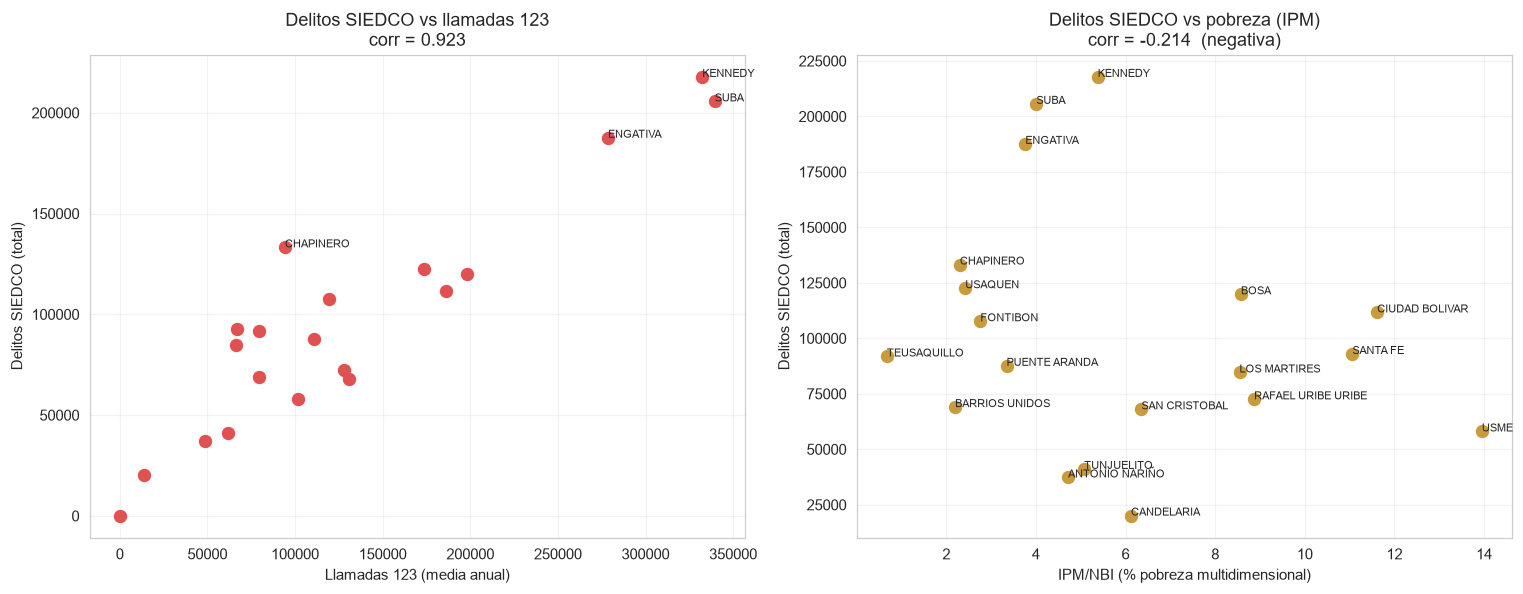

corr(SIEDCO, NUSE) = 0.923   → zonas con más delitos = más llamadas 123
corr(SIEDCO, IPM)  = -0.214   → más pobreza NO implica más volumen de delito


In [4]:
by_loc = (HIST.groupby("localidad_nombre")
              .agg(siedco=("conteo_siedco","sum"),
                   nuse=("conteo_nuse","mean"),
                   ipm=("ipm_nbi","mean"))
              .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

r1 = by_loc["siedco"].corr(by_loc["nuse"])
axes[0].scatter(by_loc["nuse"], by_loc["siedco"], color=COLORES["alto"], s=60)
axes[0].set_title(f"Delitos SIEDCO vs llamadas 123\ncorr = {r1:.3f}")
axes[0].set_xlabel("Llamadas 123 (media anual)"); axes[0].set_ylabel("Delitos SIEDCO (total)")
for _, row in by_loc.iterrows():
    if row["siedco"] > by_loc["siedco"].quantile(.8):
        axes[0].annotate(row["localidad_nombre"], (row["nuse"], row["siedco"]), fontsize=7)

d = by_loc.dropna(subset=["ipm"])
r2 = d["ipm"].corr(d["siedco"])
axes[1].scatter(d["ipm"], d["siedco"], color=COLORES["neutro"], s=60)
axes[1].set_title(f"Delitos SIEDCO vs pobreza (IPM)\ncorr = {r2:.3f}  (negativa)")
axes[1].set_xlabel("IPM/NBI (% pobreza multidimensional)"); axes[1].set_ylabel("Delitos SIEDCO (total)")
for _, row in d.iterrows():
    axes[1].annotate(row["localidad_nombre"], (row["ipm"], row["siedco"]), fontsize=7)
plt.tight_layout(); plt.show()

print(f"corr(SIEDCO, NUSE) = {r1:.3f}   → zonas con más delitos = más llamadas 123")
print(f"corr(SIEDCO, IPM)  = {r2:.3f}   → más pobreza NO implica más volumen de delito")

**Interpretación.** `conteo_siedco` y `conteo_nuse` están **fuertemente correlacionados (r = 0.92)**: las
zonas con más delito registrado también reciben más llamadas al 123. Esto valida a NUSE como señal
complementaria, pero abre una pregunta incómoda — desarrollada en la Sección 4 — sobre si ambas fuentes miden
"dónde hay más delito" o "dónde hay más actividad institucional/registro". La correlación **pobreza–volumen
de delito es negativa y débil (r = −0.21)**: las localidades más pobres **no** son las de mayor volumen de
delito registrado (ese volumen lo dominan zonas comerciales y de alta afluencia como Chapinero y Usaquén,
llenas de objetivos de hurto). Este resultado es clave para **no estigmatizar zonas pobres** como "peligrosas
en general" — la relación real depende del **tipo** de delito, no del volumen (Sección 4, Q3).

## Sección 4 — Nota de sesgo de sobre-vigilancia  ⚠️ (insumo directo para #31/#32)

> **Pregunta central:** *¿Estamos midiendo dónde ocurren más delitos, o dónde hay más presencia
> policial / registro que genera más datos?*

El dato oficial no es una foto neutral del delito: es el resultado de **qué se denuncia, dónde patrulla la
policía y qué se registra formalmente**. Un modelo entrenado sin cuidado puede aprender el patrón de
*vigilancia* en vez del patrón de *victimización*. Abajo, tres cortes con datos reales.

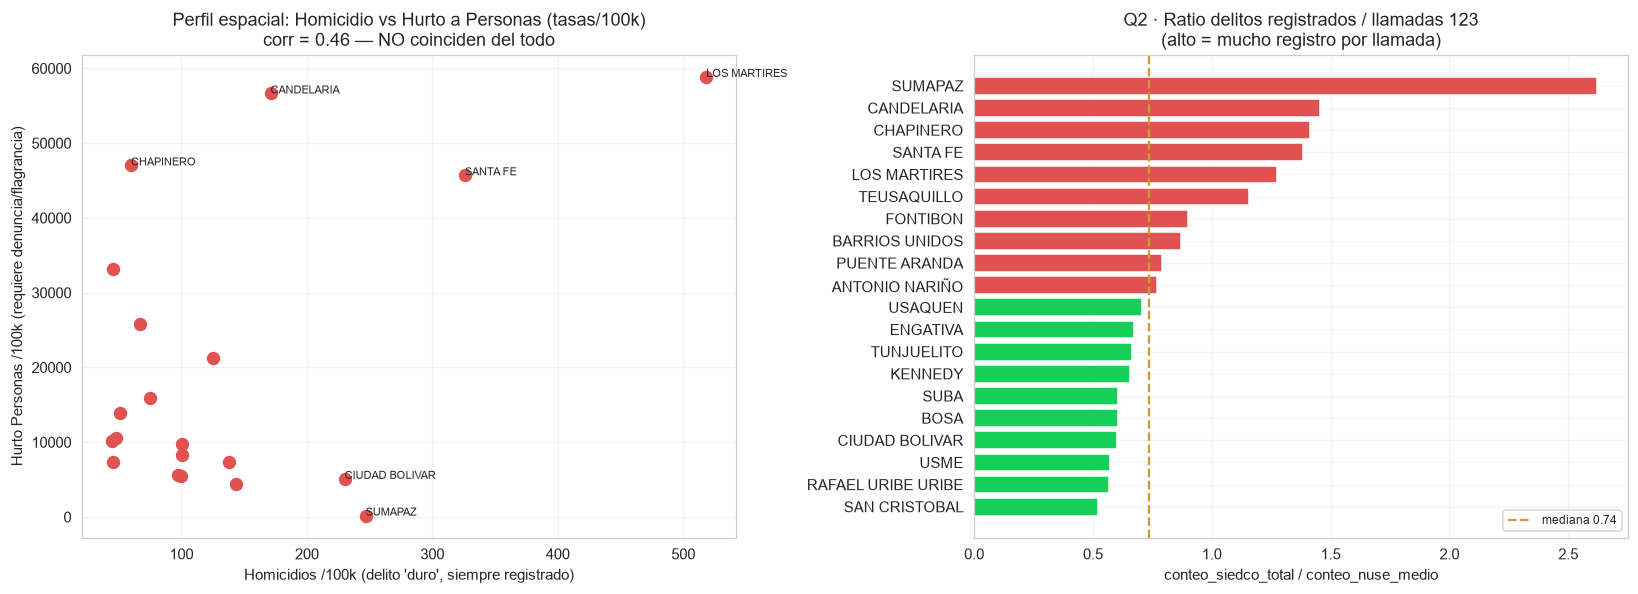

Q1 top Homicidios/100k: ['LOS MARTIRES', 'SANTA FE', 'SUMAPAZ']
Q1 top Hurto Pers/100k: ['LOS MARTIRES', 'CANDELARIA', 'CHAPINERO']
Q2 ratio más BAJO (muchas llamadas, pocos registros): ['SAN CRISTOBAL', 'RAFAEL URIBE URIBE', 'USME']
Q2 ratio más ALTO (mucho registro, pocas llamadas): ['CHAPINERO', 'CANDELARIA', 'SUMAPAZ']


In [5]:
# Agregados por localidad (2018-2024) + tasa por 100k hab
loc = (HIST.groupby(["cod_localidad","localidad_nombre"])
           .agg(pob=("poblacion","mean"), ipm=("ipm_nbi","mean"),
                nuse=("conteo_nuse","mean"), siedco_tot=("conteo_siedco","sum"))
           .reset_index())
piv = HIST.pivot_table(index="localidad_nombre", columns="tipo_delito",
                       values="conteo_siedco", aggfunc="sum")
loc = loc.merge(piv, on="localidad_nombre")
loc["pob100k"] = loc["pob"]/1e5
loc["H_r"]  = loc["H"]/loc["pob100k"]     # tasa homicidios /100k
loc["HP_r"] = loc["HP"]/loc["pob100k"]    # tasa hurto personas /100k

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
# Q1: perfil espacial Homicidio (siempre se denuncia) vs Hurto Personas (requiere denuncia/flagrancia)
rH = loc["H_r"].corr(loc["HP_r"])
axes[0].scatter(loc["H_r"], loc["HP_r"], color=COLORES["alto"], s=60)
axes[0].set_title(f"Perfil espacial: Homicidio vs Hurto a Personas (tasas/100k)\ncorr = {rH:.2f} — NO coinciden del todo")
axes[0].set_xlabel("Homicidios /100k (delito 'duro', siempre registrado)")
axes[0].set_ylabel("Hurto Personas /100k (requiere denuncia/flagrancia)")
for _, r in loc.iterrows():
    if r["H_r"] > loc["H_r"].quantile(.8) or r["HP_r"] > loc["HP_r"].quantile(.8):
        axes[0].annotate(r["localidad_nombre"], (r["H_r"], r["HP_r"]), fontsize=7)

# Q2: ratio delitos registrados / llamadas 123
loc["ratio"] = loc["siedco_tot"]/loc["nuse"].replace(0, np.nan)
ls = loc.sort_values("ratio")
colores_ratio = [COLORES["alto"] if v > loc["ratio"].median() else COLORES["bajo"] for v in ls["ratio"]]
axes[1].barh(ls["localidad_nombre"], ls["ratio"], color=colores_ratio)
axes[1].axvline(loc["ratio"].median(), color=COLORES["neutro"], ls="--",
                label=f"mediana {loc['ratio'].median():.2f}")
axes[1].set_title("Q2 · Ratio delitos registrados / llamadas 123\n(alto = mucho registro por llamada)")
axes[1].set_xlabel("conteo_siedco_total / conteo_nuse_medio"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Q1 top Homicidios/100k:", loc.sort_values('H_r',ascending=False)['localidad_nombre'].head(3).tolist())
print("Q1 top Hurto Pers/100k:", loc.sort_values('HP_r',ascending=False)['localidad_nombre'].head(3).tolist())
print("Q2 ratio más BAJO (muchas llamadas, pocos registros):",
      ls['localidad_nombre'].head(3).tolist())
print("Q2 ratio más ALTO (mucho registro, pocas llamadas):",
      ls['localidad_nombre'].tail(3).tolist())

**Q1 — ¿Qué delitos dependen de la presencia policial para registrarse?** Comparamos **Homicidios**
(siempre llega al registro: hay un cuerpo) contra **Hurto a Personas** (necesita denuncia o flagrancia, es
decir, alguien presente que lo reporte). Sus perfiles espaciales **solo coinciden a medias (r = 0.46)**: los
homicidios se concentran en Ciudad Bolívar, Santa Fe y Los Mártires, mientras el hurto per cápita dispara en
zonas **comerciales y de alta afluencia** — Chapinero, Teusaquillo, La Candelaria. Que el hurto siga a la
afluencia y al flujo de gente (y no al mapa de violencia dura) es la huella típica del sesgo: **medimos
exposición y oportunidad de registro, no necesariamente peligro real**.

**Q2 — Ratio registros/llamadas anómalo.** El ratio `SIEDCO/NUSE` es **más alto en Chapinero (1.41) y La
Candelaria (1.46)** —zonas comerciales/nocturnas— : mucho delito formalizado por cada llamada, consistente con
fuerte presencia policial y registro. Es **más bajo en el sur residencial y de mayor pobreza — San Cristóbal
(0.52), Rafael Uribe (0.57), Usme (0.57)**: muchas llamadas de auxilio que se traducen en proporcionalmente
menos registros oficiales, señal de **posible subregistro**. El mismo hecho puede volverse "dato" o no según
dónde ocurra.

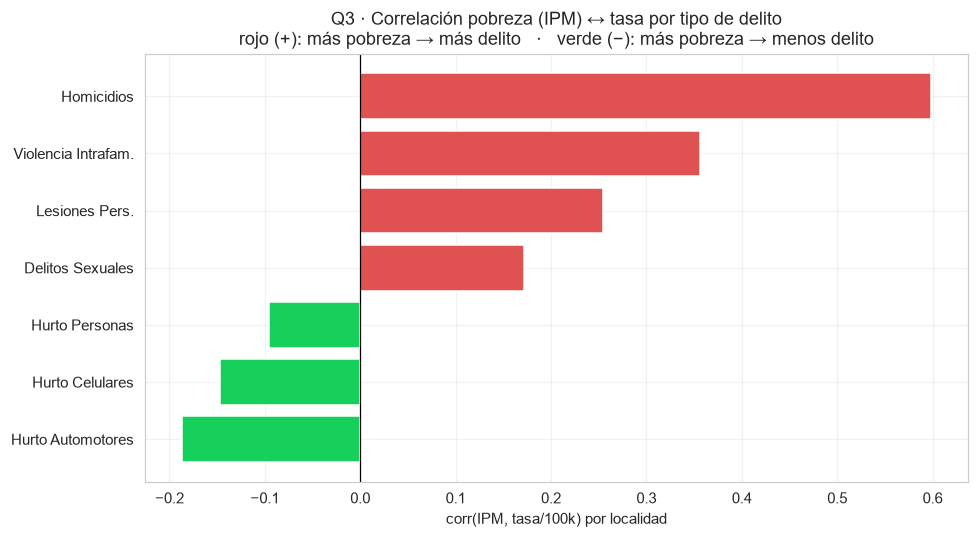

  Hurto Automotores     : -0.19
  Hurto Celulares       : -0.15
  Hurto Personas        : -0.10
  Delitos Sexuales      : +0.17
  Lesiones Pers.        : +0.25
  Violencia Intrafam.   : +0.36
  Homicidios            : +0.60


In [6]:
# Q3: ¿el IPM (pobreza) predice el TIPO de delito o solo el volumen?
d = loc.dropna(subset=["ipm"]).copy()
tipos_q3 = {"VI":"Violencia Intrafam.", "H":"Homicidios", "LP":"Lesiones Pers.",
            "DS":"Delitos Sexuales", "HP":"Hurto Personas",
            "HCE":"Hurto Celulares", "HA":"Hurto Automotores"}
corrs = {}
for t, nom in tipos_q3.items():
    d["_r"] = d[t]/d["pob100k"]
    corrs[nom] = d["ipm"].corr(d["_r"])
s = pd.Series(corrs).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = [COLORES["alto"] if v > 0 else COLORES["bajo"] for v in s.values]
ax.barh(s.index, s.values, color=colors)
ax.axvline(0, color="black", lw=.8)
ax.set_title("Q3 · Correlación pobreza (IPM) ↔ tasa por tipo de delito\n"
             "rojo (+): más pobreza → más delito   ·   verde (−): más pobreza → menos delito")
ax.set_xlabel("corr(IPM, tasa/100k) por localidad")
plt.tight_layout(); plt.show()
for nom, v in s.items():
    print(f"  {nom:22s}: {v:+.2f}")

**Q3 — La pobreza predice el *tipo*, no un "peligro general".** Al correlacionar `ipm_nbi` con la tasa de
cada delito aparece una **asimetría decisiva**: la pobreza se asocia **positivamente** con delitos de
**violencia interpersonal** — Homicidios (**+0.60**), Violencia Intrafamiliar (**+0.36**), Lesiones (+0.25) —
que **no requieren policía presente** para registrarse. Pero se asocia **negativa o nulamente** con delitos
**patrimoniales**: Hurto de Automotores (**−0.19**, hay que tener carro), Hurto de Celulares (−0.15), Hurto a
Personas (≈0). Es decir: **una zona pobre no es "más peligrosa en general"** — tiene un *perfil* distinto
(más violencia intrafamiliar, menos hurto de bienes). Colapsar todos los delitos en un único score borraría
esta distinción y **estigmatizaría** el sur de la ciudad. Por eso el target de #10 y el clustering de #27
trabajan **por tipo de delito**, no por volumen agregado.

---

## Sesgos identificados (síntesis)

Dos sesgos concretos, cada uno con su evidencia:

**1. Sesgo de sobre-vigilancia / registro en zonas comerciales.** El volumen de delito registrado sigue a la
**presencia institucional y la afluencia**, no solo a la victimización. Evidencia: `corr(SIEDCO, NUSE) = 0.92`;
el ratio registros/llamadas es máximo en Chapinero (1.41) y La Candelaria (1.46) y mínimo en San Cristóbal
(0.52), Usme y Rafael Uribe (~0.57); y el Hurto a Personas per cápita se dispara en zonas de alta afluencia
(Chapinero, Teusaquillo, Candelaria), con un perfil espacial que **solo coincide a medias con el de Homicidios
(r = 0.46)**. → El modelo puede aprender "dónde se patrulla/denuncia" en vez de "dónde ocurre el delito".

**2. Riesgo de estigmatización de zonas pobres (refutado por el dato agregado).** `corr(pobreza, volumen total
de delito) = −0.21`: las zonas más pobres **no** son las de mayor volumen. Y la pobreza predice el **tipo**:
**+0.60 con homicidio y +0.36 con violencia intrafamiliar**, pero **−0.19 con hurto de automotores y ≈0 con
hurto a personas**. → Etiquetar zonas pobres como "peligrosas en general" es empíricamente falso y debe
evitarse; el riesgo se define por tipo de delito.

### Párrafo de sesgo de sobre-vigilancia (para el informe final — 100–150 palabras)

> Los datos oficiales de criminalidad no retratan dónde ocurre el delito, sino dónde el Estado lo registra.
> En Bogotá, el delito registrado crece junto con las llamadas al 123 (correlación 0,92) y se concentra en
> zonas comerciales de alta afluencia como Chapinero y La Candelaria, donde la tasa de delitos registrados por llamada de emergencia
> supera la unidad; en cambio, en el sur residencial y más pobre —San Cristóbal, Usme, Rafael
> Uribe— abundan las llamadas pero se registran proporcionalmente menos delitos, señal de subregistro. Además,
> la pobreza se asocia con más violencia interpersonal (homicidio +0,60; violencia intrafamiliar +0,36) pero
> no con más hurto de bienes (automotores −0,19). Un modelo entrenado sin cuidado aprendería el mapa de la
> vigilancia y del registro, no el de la victimización real, y estigmatizaría barrios enteros. Por eso el
> riesgo se modela por tipo de delito y su uso exige lectura contextual, no punitiva.

*Este párrafo se copia directamente al informe final (Integrante 1 → sección compartida de evaluación / ética).*